In [2]:
scenic = pd.read_csv('eRegulon_direct_guang.tsv', delimiter = '\t')

In [3]:
otohomo = pd.read_csv('OTO_star_nothreshold_missing_le2_expressionthresh_07062026.tsv',delimiter='\t', index_col = 'MM')

In [4]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_07032026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [5]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [6]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [7]:
!pip install anndata==0.8.0

In [8]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 1.8 MB/s eta 0:00:0000:0100:01


In [16]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm
import matplotlib as mpl

In [10]:
sam_mg = SAM()
sam_mg.load_data('Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [84]:
sam_test = SAM()
sam_test.load_data('Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad')

In [11]:
sam_mo = SAM()
sam_mo.load_data('Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [12]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [72]:
sam_ac= SAM()
sam_ac.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [14]:
sam_xt = SAM()
sam_xt.load_data('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [15]:
sam_dr = SAM()
sam_dr.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [16]:
TF = pd.read_csv('Fin_TF_06012026.csv')
TF_set = set(TF['0']) 
neuropep = pd.read_csv('Neuropeptides_receptors_10202025.csv')
neuropep_list = list(neuropep['Neuropeptide names'].unique())

In [17]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [90]:
subset = sam_test.adata.X[sam_test.adata.obs_names.isin(sam_mo.adata.obs_names)]

In [94]:
len(sam_test.adata) - len(sam_mo.adata)

1375

In [95]:
1375/len(sam_test.adata)

0.01825302004513474

In [93]:
sam_mo.adata

AnnData object with n_obs × n_vars = 73955 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026', 'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_ts

In [ ]:
for item in subset[0,:]:
    print(item)

  (0, 0)	1.6433268
  (0, 7)	1.272562
  (0, 69)	1.272562
  (0, 76)	1.0439931
  (0, 86)	1.798187
  (0, 129)	1.798187
  (0, 134)	1.0439931
  (0, 138)	1.6433268
  (0, 191)	1.0439931
  (0, 204)	1.0439931
  (0, 210)	1.0439931
  (0, 227)	1.0439931
  (0, 232)	2.2909348
  (0, 254)	1.272562
  (0, 278)	1.6433268
  (0, 323)	1.6433268
  (0, 329)	2.48586
  (0, 366)	1.0439931
  (0, 395)	1.0439931
  (0, 422)	3.0142682
  (0, 443)	1.272562
  (0, 444)	1.0439931
  (0, 487)	1.0439931
  (0, 492)	1.272562
  (0, 501)	2.2909348
  :	:
  (0, 18997)	1.0439931
  (0, 19001)	1.0439931
  (0, 19011)	1.4698224
  (0, 19034)	2.949635
  (0, 19038)	2.1826148
  (0, 19049)	1.0439931
  (0, 19051)	2.574261
  (0, 19052)	1.0439931
  (0, 19057)	1.0439931
  (0, 19091)	1.272562
  (0, 19112)	1.0439931
  (0, 19118)	1.9380239
  (0, 19131)	1.0439931
  (0, 19171)	1.272562
  (0, 19178)	2.0654964
  (0, 19202)	1.272562
  (0, 19213)	1.0439931
  (0, 19249)	1.4698224
  (0, 19259)	1.0439931
  (0, 19262)	3.192421
  (0, 19267)	1.4698224
  (0, 19

In [ ]:
for item in sam_mo.adata.X[0,:]:
    print(item)

  (0, 0)	1.650137
  (0, 7)	1.2784344
  (0, 69)	1.2784344
  (0, 76)	1.0491548
  (0, 86)	1.8053226
  (0, 129)	1.8053226
  (0, 134)	1.0491548
  (0, 138)	1.650137
  (0, 191)	1.0491548
  (0, 204)	1.0491548
  (0, 210)	1.0491548
  (0, 227)	1.0491548
  (0, 232)	2.2989016
  (0, 254)	1.2784344
  (0, 278)	1.650137
  (0, 323)	1.650137
  (0, 329)	2.4940846
  (0, 366)	1.0491548
  (0, 395)	1.0491548
  (0, 422)	3.0230389
  (0, 443)	1.2784344
  (0, 444)	1.0491548
  (0, 487)	1.0491548
  (0, 492)	1.2784344
  (0, 501)	2.2989016
  :	:
  (0, 18997)	1.0491548
  (0, 19001)	1.0491548
  (0, 19011)	1.4762236
  (0, 19034)	2.9583492
  (0, 19038)	2.190422
  (0, 19049)	1.0491548
  (0, 19051)	2.5825913
  (0, 19052)	1.0491548
  (0, 19057)	1.0491548
  (0, 19091)	1.2784344
  (0, 19112)	1.0491548
  (0, 19118)	1.945425
  (0, 19131)	1.0491548
  (0, 19171)	1.2784344
  (0, 19178)	2.0731182
  (0, 19202)	1.2784344
  (0, 19213)	1.0491548
  (0, 19249)	1.4762236
  (0, 19259)	1.0491548
  (0, 19262)	3.2013354
  (0, 19267)	1.4762236

In [18]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [21]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [56]:
obs_names = sam_cj.adata.obs_names

In [58]:
sam_cj.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_genes,n_counts,key,hicat_merged,subclass_id_label_mapping,subclass_id_label_lc,leiden_clusters,...,ss_class,ss_subclass_nounlabeled_astro,ss_subclass_v2,ss_subclass_v2_nounlabeled,ss_subclass_nounlabeled_nmm,ss_subclass_v3_nounlabeled,subclass_id_label_crossed,ss_subclass_nounlabeled_nmm_v2,ss_subclass_nounlabeled_nmm_v3_nn,neurotransmitter_v2
AAACCCAAGACGACTG Run 11 sample 8,CJ,1455.0,797,797,1455.0,Run 11 sample 8,341,085 SI-MPO-LPO Lhx8 Gaba,362,90,...,11 CNU-HYa GABA,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,Gaba
AAACCCAGTCGAAACG Run 11 sample 8,CJ,1489.0,763,763,1489.0,Run 11 sample 8,152,128 VMH Fezf1 Glut,496,23,...,14 HY Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,Glut
AAACCCAGTGCCGGTT Run 11 sample 8,CJ,1874.0,951,951,1874.0,Run 11 sample 8,230,090 BST-MPN Six3 Nrgn Gaba,501,25,...,11 CNU-HYa GABA,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,Gaba
AAACCCATCATAGACC Run 11 sample 8,CJ,4032.0,1650,1650,4032.0,Run 11 sample 8,152,129 VMH Nr5a1 Glut,74,11,...,14 HY Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,Glut
AAACCCATCATGTCTT Run 11 sample 8,CJ,1857.0,1016,1016,1857.0,Run 11 sample 8,564,092 TMv-PMv Tbx3 Hist-Gaba,73,35,...,12 HY GABA,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,Gaba-Hist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCATGGAGG Run 11 sample 7,CJ,13303.0,2931,2931,13303.0,Run 11 sample 7,228,Unlabeled,179,13,...,10 LSX GABA,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,069 LSX Nkx2-1 Gaba,Gaba
TTTGGTTTCCACAGCG Run 11 sample 7,CJ,6076.0,2117,2117,6076.0,Run 11 sample 7,571,125 DMH Hmx2 Glut,113,29,...,14 HY Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,Glut
TTTGGTTTCCATCAGA Run 11 sample 7,CJ,13270.0,3222,3222,13270.0,Run 11 sample 7,277,132 AHN-RCH-LHA Otp Fezf1 Glut,25,85,...,14 HY Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,Glut
TTTGGTTTCGGTGCAC Run 11 sample 7,CJ,7299.0,2248,2248,7299.0,Run 11 sample 7,152,129 VMH Nr5a1 Glut,93,21,...,14 HY Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,Glut


In [25]:
for item in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique():
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ct':
        parent_dict[item] = 'hypo'

In [26]:
parent_dict['hypo'] = 'hypo'

In [27]:
df = pd.read_csv('Neuropep_TF_corr_hypo_07072026.csv',index_col = 'Unnamed: 0')

In [28]:
df

,"('Tac1', 'Ar')","('Tac2', 'Ar')","('Prok2', 'Dbp')","('Gal', 'Esr1')","('Pomc', 'Esr1')","('Agrp', 'Fli1')","('Vgf', 'Fos')","('Avp', 'Fosl2')","('Oxt', 'Fosl2')","('Vgf', 'Fosl2')",...,"('Apln', 'Nkx2-2')","('Npvf', 'Nkx2-2')","('Prok2', 'Nr1d1')","('Crh', 'Nr3c1')","('Tac2', 'Nr5a2')","('Gnrh1', 'Otx1')","('Crh', 'Pou3f2')","('Prok2', 'Pparg')","('Qrfp', 'Rfx2')","('Dbi', 'Tcf12')"
mm,0.405647,0.309298,0.597400,0.424799,0.332997,0.621393,0.397635,0.313507,0.446301,0.504516,...,0.361732,0.848023,0.732503,0.361370,0.314587,0.897795,0.411288,0.513059,0.466379,0.444830
mo,-0.029635,0.363362,0.584099,0.161575,0.378798,-0.023448,0.596499,0.502868,0.504534,0.160793,...,-0.106819,0.178497,0.586573,0.093301,-0.067749,0.051493,0.296989,0.237457,0.453217,0.186556
cj,-0.133082,NaN,NaN,0.204895,0.364221,0.173218,NaN,0.079266,0.007874,NaN,...,0.212597,0.245350,0.146581,-0.051357,NaN,0.082487,0.053573,-0.061938,0.553362,0.093397
ac,0.039950,-0.070885,-0.041549,-0.011334,-0.049439,0.000812,0.363112,0.243679,0.190604,0.267058,...,NaN,0.435344,-0.127218,-0.044908,-0.063537,NaN,0.113215,-0.057210,NaN,-0.104687
xt,-0.082981,-0.080483,0.052397,-0.032104,0.044914,0.054258,0.330200,0.228089,0.143322,0.478085,...,0.146253,0.238431,0.066967,0.012333,-0.014465,0.777094,0.153849,0.132124,0.231230,0.116055
dr,0.187657,NaN,NaN,0.104263,-0.093389,0.002980,0.177499,0.120723,0.033769,0.173890,...,NaN,NaN,-0.049994,-0.055129,NaN,NaN,0.065537,0.063050,NaN,0.103446


In [29]:
import ast


mm_row = df.loc['mm',:]
tf_target_corrs = {}
for pair_label, r in mm_row.items():
    _, tf_gene = ast.literal_eval(pair_label)   # pair_label is "('NP', 'TF')"
    if pd.notna(r):
        tf_target_corrs.setdefault(tf_gene, []).append(float(r))

In [30]:
tf_target_corrs.keys()

dict_keys(['Ar', 'Dbp', 'Esr1', 'Fli1', 'Fos', 'Fosl2', 'Foxn4', 'Hlf', 'Hmx2', 'Hmx3', 'Isl1', 'Lhx9', 'Nkx2-1', 'Nkx2-2', 'Nr1d1', 'Nr3c1', 'Nr5a2', 'Otx1', 'Pou3f2', 'Pparg', 'Rfx2', 'Tcf12'])

In [31]:
import ast

# Number of unregulated control genes to pick per regulated NP-TF pair.
# n_controls = 1 reproduces the original "single best match" behavior.
n_controls = 5

TFl = tf_target_corrs.keys()
# For each TF, the mouse (mm) NP-TF correlations of its regulated pairs, read from
# df (the regulated NP-TF table). These per-pair values replace the single fixed
# 0.411287891721808: each control gene is matched to a specific regulated pair.
mm_row = df.loc['mm',:]
tf_target_corrs = {}
for pair_label, r in mm_row.items():
    _, tf_gene = ast.literal_eval(pair_label)   # pair_label is "('NP', 'TF')"
    if pd.notna(r):
        tf_target_corrs.setdefault(tf_gene, []).append(float(r))

neuropep_set = set(neuropep_list)

scenic_g_TF = []
mg_vals = []
for TF in TFl:
    tf_expr = all_exp_ct[:, gene_dict_mg[TF]]

    # genes this TF is annotated to regulate in SCENIC (excluded from the control)
    regulated_by_TF = set(scenic[scenic['TF'] == TF]['Gene'])

    # candidate control genes: present in the ortholog table and the mouse matrix,
    # not a neuropeptide, and NOT regulated by this TF; score each with pearsonr
    corrs = {}
    for g in dict.fromkeys(otohomo.index):
        if (g in gene_dict_mg and g != TF
                and g not in neuropep_set and g not in regulated_by_TF and g not in TF_set):
            r = stats.pearsonr(all_exp_ct[:, gene_dict_mg[g]], tf_expr)[0]
            if r > 0.3:
                corrs[g] = r
    corrs = pd.Series(corrs)

    # for each regulated pair's mouse correlation, take the n_controls closest
    # unused candidates (each candidate is used at most once)
    used = set()
    for target_r in tf_target_corrs[TF]:
        avail = corrs.drop(index=used, errors='ignore')
        if avail.empty:
            break
        closest = (avail - target_r).abs().nsmallest(n_controls).index
        for best in closest:
            used.add(best)
            scenic_g_TF.append((best, TF))
            mg_vals.append(corrs[best])

/scratch/miniconda/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [33]:
len(scenic_g_TF)

155

In [34]:
len(df.columns)

31

In [79]:
stats.pearsonr(all_exp_ct[:,gene_dict_mg['Togaram1']],all_exp_ct[:,gene_dict_mg['Ar']])

(0.4056712838773413, 0.0003699610602926015)

In [36]:
scenic_np_tf_flat = [item for tup in scenic_g_TF for item in tup]

In [37]:
mg_exp ={i:i for i in scenic_np_tf_flat}
mo_exp = {i:otohomo.loc[i,'MO'] for i in scenic_np_tf_flat}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in scenic_np_tf_flat}
ac_exp = {i:otohomo.loc[i,'AC'] for i in scenic_np_tf_flat}
xt_exp = {i:otohomo.loc[i,'XT'] for i in scenic_np_tf_flat}
dr_exp = {i:otohomo.loc[i,'DR'] for i in scenic_np_tf_flat}

In [38]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = scenic_g_TF)

In [39]:
df_corr['mm'] = mg_vals

In [40]:
def corr_org(org, adata, gene_name_conv, level, glist):
    fin_df = pd.DataFrame(index = glist, columns = [org])
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    all_exp_ct = np.zeros((adata.obs[level].nunique(),len(adata.var_names)))
    ctl = adata.obs[level].unique()
    for i in range(len(ctl)):
        all_exp_ct[i,:] = np.average(exp[adata.obs[level] == ctl[i],:], axis = 0)
    for item in glist:
        g1 = gene_name_conv[item[0]]
        g2 = gene_name_conv[item[1]]
        if type(g1) == str and type(g2) == str and g1 in gene_dict and g2 in gene_dict:
            fin_df.loc[[tuple(item)], org] = stats.pearsonr(all_exp_ct[:,gene_dict[g1]], all_exp_ct[:,gene_dict[g2]])[0]
    return(fin_df)

In [41]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [42]:
hl_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [43]:
hypo_adata_mo = sam_mo.adata[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].isin(hl_mo)]
hypo_adata_cj = sam_cj.adata[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_cj)]
hypo_adata_ac = sam_ac.adata[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_ac)]
hypo_adata_xt = sam_xt.adata[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_xt)]
hypo_adata_dr = sam_dr.adata[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_dr)]

In [44]:
df_corr['mo'] = corr_org('mo',hypo_adata_mo,mo_exp,'ss_subclass_nounlabeled_03102026',df_corr.index)
df_corr['cj'] = corr_org('cj',hypo_adata_cj,cj_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['ac'] = corr_org('ac',hypo_adata_ac,ac_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['xt'] = corr_org('xt',hypo_adata_xt,xt_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['dr'] = corr_org('dr',hypo_adata_dr,dr_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)

In [45]:
df_corr = df_corr.T

In [46]:
swapped = [(b, a) for a, b in df_corr.columns]

# 2. Sort by the new first element (stable sort preserves relative order
#    within each group)
sorted_swapped = sorted(range(len(swapped)), key=lambda i: swapped[i][0])

# 3. Reindex columns
df_swapped = df_corr.iloc[:, sorted_swapped]

In [47]:
df_swapped = df_swapped.astype(float)

In [48]:
dfcorr_flat = list(set([item for tup in df_swapped.columns for item in tup]))

In [49]:
df_swapped

,"(Togaram1, Ar)","(Fam107a, Ar)","(Arfgap1, Ar)","(Ptbp2, Ar)","(Spopl, Ar)","(Trim3, Ar)","(Rnf157, Ar)","(Gng7, Ar)","(Jakmip2, Ar)","(Fam171b, Ar)",...,"(Creld2, Rfx2)","(Pias3, Rfx2)","(Ros1, Rfx2)","(Slc35d2, Rfx2)","(Il17rd, Rfx2)","(Nalcn, Tcf12)","(Dhx35, Tcf12)","(Usp44, Tcf12)","(Tmem88, Tcf12)","(Polr3d, Tcf12)"
mm,0.405671,0.405691,0.405857,0.406116,0.406163,0.309208,0.309062,0.309540,0.309553,0.308861,...,0.466251,0.466622,0.466083,0.466700,0.466732,0.444693,0.444548,0.445311,0.445334,0.445415
mo,0.101959,0.189971,-0.039482,0.267375,0.002679,0.141864,-0.111125,-0.019178,-0.153804,0.065463,...,0.171989,-0.038231,0.332086,0.366994,0.225862,0.234793,0.034713,0.157709,-0.104759,0.266363
cj,-0.023106,0.323736,-0.004982,0.157809,0.125320,0.214306,0.163932,0.070297,-0.022130,-0.025993,...,0.399609,NaN,0.055059,NaN,-0.120738,-0.157683,-0.199061,0.160856,NaN,-0.073607
ac,0.022001,0.192494,0.081524,0.030411,0.042747,-0.114895,-0.074373,-0.027426,-0.092346,0.226143,...,NaN,NaN,NaN,NaN,NaN,-0.004605,-0.091006,0.217379,-0.050445,0.211240
xt,0.323271,0.091751,0.112643,0.015113,0.190437,0.348148,0.070297,0.169213,0.445165,NaN,...,0.423672,0.194006,0.018752,0.416429,-0.040622,0.185673,0.205739,0.274232,-0.003755,0.048545
dr,0.116396,0.013898,-0.001391,0.001506,0.173214,0.141871,0.050036,-0.049961,0.351525,0.245903,...,NaN,NaN,0.061597,0.066727,0.664484,0.313230,0.167014,0.201017,0.001785,0.071059


In [17]:
df_swapped.to_csv('TF_unregulated_corr_hypo_ncontrols5_07092026.csv')

In [18]:
df_swapped = pd.read_csv('TF_unregulated_corr_hypo_ncontrols5_07092026.csv',index_col = 'Unnamed: 0')

In [19]:
df_swapped

,"('Togaram1', 'Ar')","('Fam107a', 'Ar')","('Arfgap1', 'Ar')","('Ptbp2', 'Ar')","('Spopl', 'Ar')","('Trim3', 'Ar')","('Rnf157', 'Ar')","('Gng7', 'Ar')","('Jakmip2', 'Ar')","('Fam171b', 'Ar')",...,"('Creld2', 'Rfx2')","('Pias3', 'Rfx2')","('Ros1', 'Rfx2')","('Slc35d2', 'Rfx2')","('Il17rd', 'Rfx2')","('Nalcn', 'Tcf12')","('Dhx35', 'Tcf12')","('Usp44', 'Tcf12')","('Tmem88', 'Tcf12')","('Polr3d', 'Tcf12')"
mm,0.405671,0.405691,0.405857,0.406116,0.406163,0.309208,0.309062,0.309540,0.309553,0.308861,...,0.466251,0.466622,0.466083,0.466700,0.466732,0.444693,0.444548,0.445311,0.445334,0.445415
mo,0.101959,0.189971,-0.039482,0.267375,0.002679,0.141864,-0.111125,-0.019178,-0.153804,0.065463,...,0.171989,-0.038231,0.332086,0.366994,0.225862,0.234793,0.034713,0.157709,-0.104759,0.266363
cj,-0.023106,0.323736,-0.004982,0.157809,0.125320,0.214306,0.163932,0.070297,-0.022130,-0.025993,...,0.399609,NaN,0.055059,NaN,-0.120738,-0.157683,-0.199061,0.160856,NaN,-0.073607
ac,0.022001,0.192494,0.081524,0.030411,0.042747,-0.114895,-0.074373,-0.027426,-0.092346,0.226143,...,NaN,NaN,NaN,NaN,NaN,-0.004605,-0.091006,0.217379,-0.050445,0.211240
xt,0.323271,0.091751,0.112643,0.015113,0.190437,0.348148,0.070297,0.169213,0.445165,NaN,...,0.423672,0.194006,0.018752,0.416429,-0.040622,0.185673,0.205739,0.274232,-0.003755,0.048545
dr,0.116396,0.013898,-0.001391,0.001506,0.173214,0.141871,0.050036,-0.049961,0.351525,0.245903,...,NaN,NaN,0.061597,0.066727,0.664484,0.313230,0.167014,0.201017,0.001785,0.071059


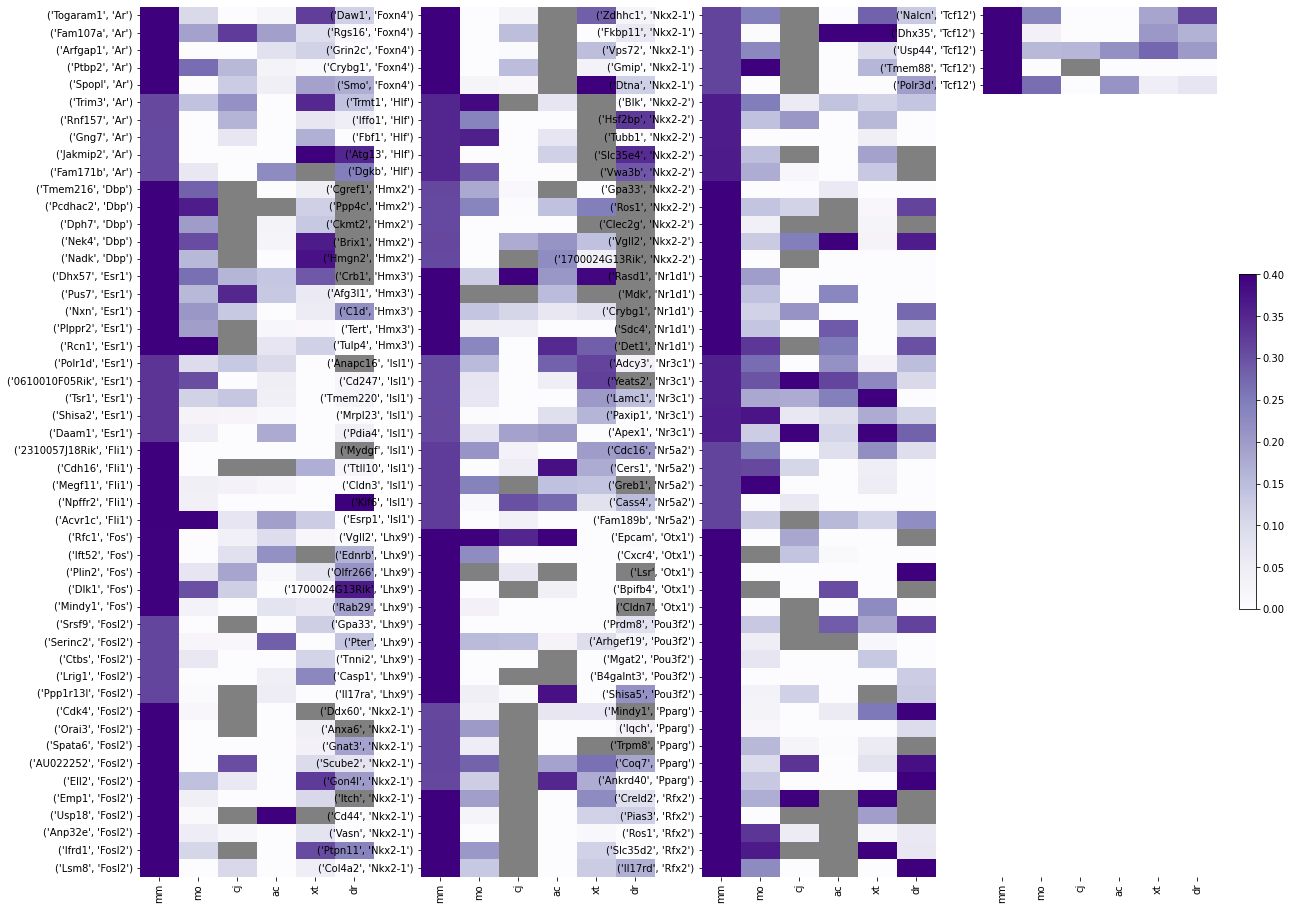

In [21]:
n_per_panel = 50
chunks = [df_swapped.iloc[:, i:i + n_per_panel].T
          for i in range(0, df_swapped.shape[1], n_per_panel)]

cmap = mpl.cm.get_cmap("Purples").copy()
cmap.set_bad('grey')  # sets NaN color

fig, axes = plt.subplots(1, len(chunks), figsize=(20, 16))

for ax, chunk in zip(axes, chunks):
    sns.heatmap(chunk, cmap=cmap, vmax=.4, vmin=0, ax=ax, cbar=False)
    # hold the cell height constant so the short final panel matches the full ones
    ax.set_ylim(n_per_panel, 0)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=.4), cmap=cmap),
             ax=axes, fraction=.015, pad=.02)

plt.savefig('Figures/Figures_07122026/S35_RandomG_TF_relationship_ncontrols5_07122026.svg')
plt.savefig('Figures/Figures_07122026/S35_RandomG_TF_relationship_ncontrols5_07122026.pdf')